# Chapter 26: How to Be Ready Without Being Certain
Turn probabilities into actions with explicit costs, evaluate combinations, and
retain a forecast journal. Synthetic outcomes make the scoring loop inspectable.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.special import expit,logit
rng=begin(26); p=rng.uniform(.05,.95,3000); outcomes=rng.binomial(1,p)
false_alarm,miss=2.,8.; threshold=false_alarm/(false_alarm+miss)

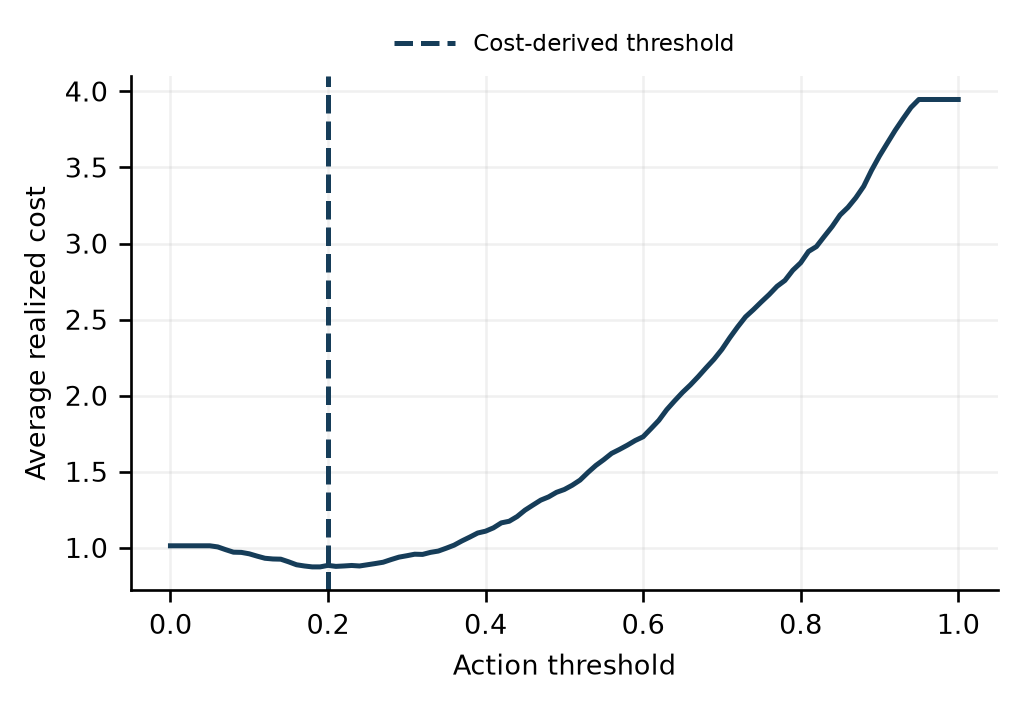

In [2]:
thresholds=np.linspace(0,1,101); losses=[]
for cut in thresholds:
    action=p>=cut; losses.append(np.mean(false_alarm*(action & (outcomes==0))+miss*((~action)&(outcomes==1))))
plt.figure(); plt.plot(thresholds,losses); plt.axvline(threshold,ls='--',label='Cost-derived threshold'); plt.xlabel('Action threshold'); plt.ylabel('Average realized cost'); plt.legend(fontsize=7)
save(26,1,'A probability becomes a decision through costs','Synthetic events with false-alarm cost two and miss cost eight. The Bayes threshold is 0.2 when probabilities are calibrated and costs fixed.','## Section Three: The Practice')

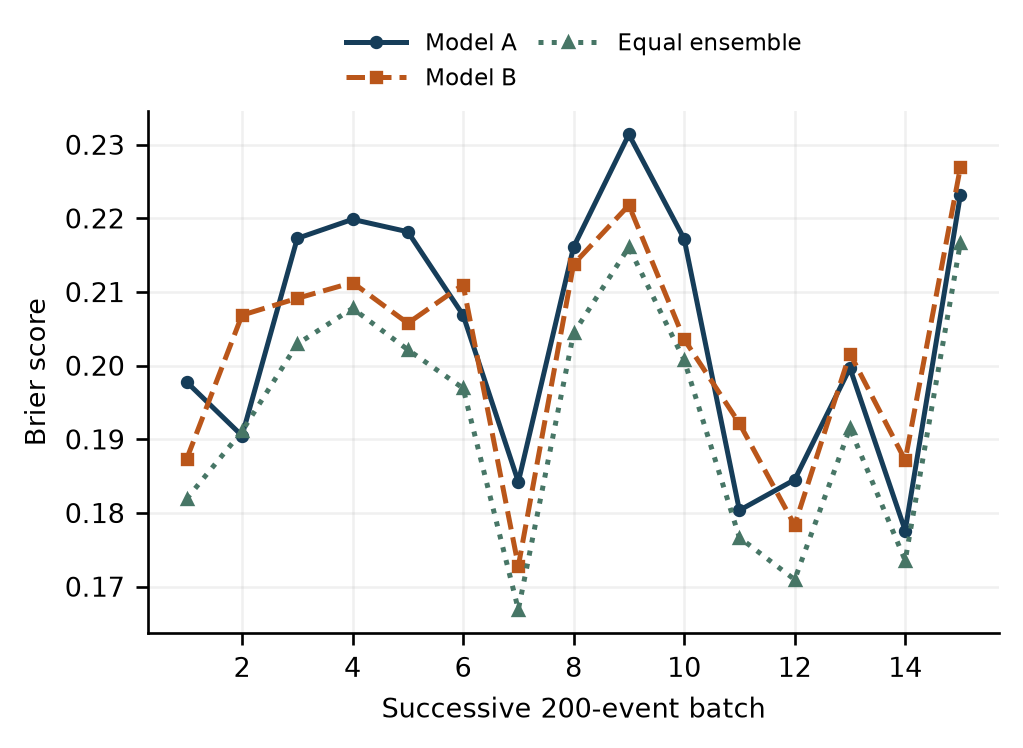

In [3]:
a=expit(logit(p)+rng.normal(0,.8,len(p))); b=expit(logit(p)+rng.normal(0,.8,len(p))); combined=(a+b)/2
plt.figure()
for name,pred in [('Model A',a),('Model B',b),('Equal ensemble',combined)]:
    block=[brier(pred[i:i+200],outcomes[i:i+200]) for i in range(0,len(p),200)]; plt.plot(np.arange(1,len(block)+1),block,label=name)
plt.xlabel('Successive 200-event batch'); plt.ylabel('Brier score'); plt.legend(fontsize=7)
save(26,2,'A journal makes the comparison repeatable','Synthetic forecasts constructed from latent event propensities and independent noise, then scored against generated outcomes in successive batches. The ensemble uses fixed equal weights; this is not a historical timestamped journal.','## Section Four: The Full Methodology')

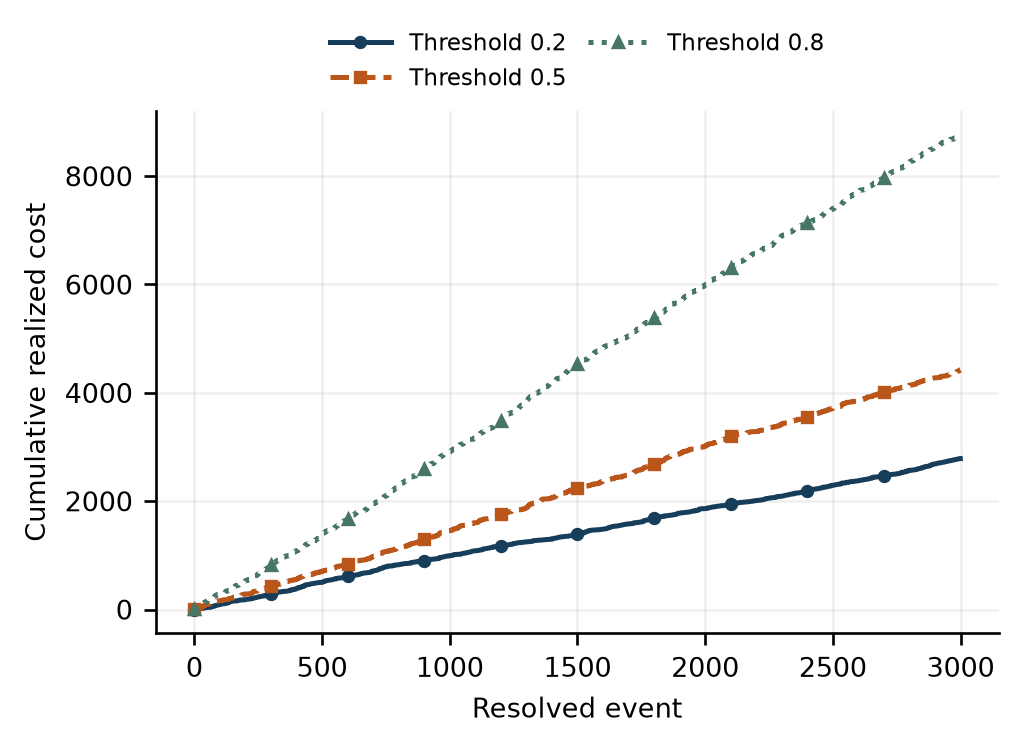

In [4]:
plt.figure()
for cut in [.2,.5,.8]:
    action=combined>=cut; loss=false_alarm*(action & (outcomes==0))+miss*((~action)&(outcomes==1)); plt.plot(np.cumsum(loss),label=f'Threshold {cut}')
plt.xlabel('Resolved event'); plt.ylabel('Cumulative realized cost'); plt.legend(fontsize=7)
save(26,3,'Evaluate the decisions as well as the forecasts','The same synthetic ensemble and outcomes under different action thresholds. Costs accumulate even when forecast accuracy appears acceptable.','## Section Five: The Return')
import pandas as pd
journal=pd.DataFrame({'event':np.arange(len(p)),'probability':combined,'outcome':outcomes,'threshold':threshold})
import os
journal.to_csv(Path(os.environ.get('FORECAST_OUTPUT',project/'companion'))/'results/ch26-forecast-journal.csv',index=False)

## Limits and exercise
Reverse the costs and rerun. A 90% interval is not inherently better than a 60%
interval; evaluate calibration, sharpness and usefulness for the actual decision.
A single outcome contributes to a proper score even though it cannot establish
calibration by itself.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV event_id,probability,outcome with p in [0,1], outcome 0/1 for CLI scoring; retain unresolved cases in the journal, not this scoring file. Config false_alarm_cost and miss_cost are strictly positive and finite for the supplied adapter. Record forecast timestamps, event definition and action constraints separately; predictions must predate outcomes.

Minimal **format illustration**, not sufficient training data:

```csv
event_id,probability,outcome
E1,0.3,1
E2,0.1,0
```

## Explain the mechanism

Readiness converts uncertain beliefs into contingent actions. A threshold expresses relative consequences, not how confident one should feel. A forecast and the policy using it need separate evaluation because either can fail.

## Work through the arithmetic

With false-alarm cost 2 and miss cost 8, act when p>=2/(2+8)=.2 under the adapter’s tie rule. At p=.3, acting costs 2×.7=1.4 in expectation; not acting costs 8×.3=2.4. A rare event can therefore justify action well below a .5 threshold.

## Adapt the lesson to reader data

Replace the synthetic journal with timestamped event probabilities and outcomes; retain baseline predictions made on the same events. Change costs before recomputing policy decisions. If historical decisions were different, do not represent newly optimized retrospective decisions as actions actually taken.

For this chapter, settle these questions before fitting: What actions are available? What is the cost of a false alarm and a miss? Are costs constant and probabilities relevant/calibrated? What capacity or feasibility constraints apply?

## Interpret the actual lesson outputs

The lesson’s events and journal are synthetic, with fixed equal ensemble weights. The cost curve applies alternate thresholds to the same outcomes; choosing its minimum and reporting that same minimum as future performance would overfit policy selection.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `event_id,probability,outcome,action,loss,cumulative_loss`.
- `summary.json`: `threshold,brier,mean_loss,best_constant_policy_hindsight_cost` plus method, interpretation, assumptions, not_done and status.

The adapter requires resolved events and strictly positive finite costs. It acts at p>=threshold. The reported best constant policy is a hindsight diagnostic, not a pre-recorded baseline. It reports Brier alongside decision loss; chapter 9 adds a fuller calibration diagnosis.

## Decide what the evidence supports

The threshold formula assumes zero cost for correct actions and fixed misclassification costs. Capacity limits, intervention effectiveness and heterogeneous costs can require a different optimization. A good score does not automatically imply useful decisions, and one outcome cannot establish calibration.

Without credible costs, present the threshold/cost tradeoff and ask for the material missing preference rather than declare an optimal action. With unresolved outcomes, log expected decisions but do not compute realized loss. Uncertain probabilities warrant sensitivity around the decision boundary.

The applied deliverable must make these items inspectable: `results.csv` columns: `event_id,probability,outcome,action,loss,cumulative_loss`; `summary.json` keys: `threshold,brier,mean_loss,best_constant_policy_hindsight_cost` plus method, interpretation, assumptions, not_done and status. Return loss table, threshold and assumptions, event-level probabilities/actions, realized costs and proper scores where resolved, benchmark policies, unresolved counts and revision plan.

## Three exercises with worked solutions

### Exercise 1

False alarm 9, miss 1: optimal simple threshold?

**Worked solution.** 9/(9+1)=.9.

### Exercise 2

p=.4, false alarm 2, miss 8: expected costs?

**Worked solution.** Act: 2×.6=1.2; do not act: 8×.4=3.2. Act under the simple loss table.

### Exercise 3

A threshold tuned to all outcomes has lower realized cost. Is deployment improvement established?

**Worked solution.** No. Freeze it and evaluate later events; retrospective optimization is not untouched policy evidence.

## Business-reader application

Use this request with the skill:

> Use chapter 26 to translate probabilities.csv into an explicit action policy under our costs, preserve unresolved cases and evaluate both probability quality and realized decision loss.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch26.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch26.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(26, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch26-workshop-results.csv', index=False)
_ = (workshop_output/'ch26-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Cost-weighted decision threshold applied to probability forecasts
Status: passed

Interpretation: Acting when probability >= 0.200 (false alarm 2, miss 8) gave mean loss 0.84 per event over 200 events; the best constant policy in hindsight costs 1.07. The threshold is Bayes-optimal only for calibrated probabilities and the stated loss structure; the hindsight cost is a diagnostic, not a preselected baseline.

Assumptions:
  - Probabilities are calibrated
  - Costs are fixed per event and known in advance
Not done:
  - No recalibration of the probabilities before thresholding
  - No value-of-information analysis for waiting

Evidence:
  threshold: 0.2
  brier: 0.1845
  mean_loss: 0.84
  best_constant_policy_hindsight_cost: 1.07

Table: 200 rows, columns ['event_id', 'probability', 'outcome', 'action', 'loss', 'cumulative_loss']

event_id  probability  outcome  action  loss  cumulative_loss
      e0        0.498        0    True   2.0              2.0
      e1        0.477       